In [1]:
import random

GRID_SIZE = 10

class SnakeGame:
    def __init__(self):
        self.reset()

    def reset(self):
        self.direction = RIGHT
        self.snake = [(GRID_SIZE // 2, GRID_SIZE // 2)]
        self.food = self.spawn_food()
        self.done = False
        self.score = 0
        return self.snake, self.food

    def spawn_food(self):
        while True:
            pos = (
                random.randint(0, GRID_SIZE - 1),
                random.randint(0, GRID_SIZE - 1)
            )
            if pos not in self.snake:
                return pos

In [2]:
# Snake object
def move_snake(snake, direction):
    head_x, head_y = snake[0]
    dx, dy = direction
    new_head = (head_x + dx, head_y + dy)
    snake.insert(0, new_head)
    return new_head

In [3]:
# Collision checker
def is_collision(pos, snake, grid_size):
    x, y = pos
    if x < 0 or x >= grid_size or y < 0 or y >= grid_size:
        return True
    if pos in snake:
        return True
    return False

In [4]:
# State Extraction function
def get_state(snake, food, direction, grid_size):
    head_x, head_y = snake[0]
    food_x, food_y = food

    # Food direction
    food_left = int(food_x < head_x)
    food_right = int(food_x > head_x)
    food_up = int(food_y < head_y)
    food_down = int(food_y > head_y)

    # Danger detection
    danger_up = int(is_collision((head_x, head_y - 1), snake, grid_size))
    danger_down = int(is_collision((head_x, head_y + 1), snake, grid_size))
    danger_left = int(is_collision((head_x - 1, head_y), snake, grid_size))
    danger_right = int(is_collision((head_x + 1, head_y), snake, grid_size))

    # Current direction
    dir_up = int(direction == UP)
    dir_down = int(direction == DOWN)
    dir_left = int(direction == LEFT)
    dir_right = int(direction == RIGHT)

    return (
        food_left, food_right, food_up, food_down,
        danger_up, danger_down, danger_left, danger_right,
        dir_up, dir_down, dir_left, dir_right
    )

In [5]:
# Action
UP = (0, -1)
RIGHT = (1, 0)
DOWN = (0, 1)
LEFT = (-1, 0)
DIRECTIONS = [UP, RIGHT, DOWN, LEFT]

# Action contants
STRAIGHT = 0
TURN_LEFT = 1
TURN_RIGHT = 2

# Direction mapping
def get_new_direction(current_direction, action):
    idx = DIRECTIONS.index(current_direction)

    if action == STRAIGHT:
        return current_direction
    elif action == TURN_LEFT:
        return DIRECTIONS[(idx - 1) % 4]
    elif action == TURN_RIGHT:
        return DIRECTIONS[(idx + 1) % 4]
    else:
        raise ValueError("Invalid action")

# Reward function
def step(game, action):
    if game.done:
        return None, 0, True

    game.direction = get_new_direction(game.direction, action)
    new_head = move_snake(game.snake, game.direction)

    if is_collision(new_head, game.snake[1:], GRID_SIZE):
        game.done = True
        return None, -10, True

    reward = 0
    if new_head == game.food:
        game.score += 1
        reward = 10
        game.food = game.spawn_food()
    else:
        game.snake.pop()

    return game.snake, reward, False

In [6]:
# Reward & Loss function inside

# Distance helper
def manhattan_distance(p1, p2):
    return abs(p1[0] - p2[0]) + abs(p1[1] - p2[1])


def step(game, action):
    if game.done:
        return None, 0, True

    old_distance = manhattan_distance(game.snake[0], game.food)

    game.direction = get_new_direction(game.direction, action)
    new_head = move_snake(game.snake, game.direction)

    # Collision
    if is_collision(new_head, game.snake[1:], GRID_SIZE):
        game.done = True
        return None, -10, True

    reward = -0.1  # step penalty
    new_distance = manhattan_distance(new_head, game.food)

    # Distance shaping
    if new_distance < old_distance:
        reward += 1
    else:
        reward -= 1

    # Food
    if new_head == game.food:
        game.score += 1
        reward = 10
        game.food = game.spawn_food()
    else:
        game.snake.pop()

    return game.snake, reward, False

In [7]:
# Q-Learning Algorithm

import random
from collections import defaultdict

class QLearningAgent:
    def __init__(
        self,
        actions,
        alpha=0.1,
        gamma=0.9,
        epsilon=1.0,
        epsilon_min=0.01,
        epsilon_decay=0.995
    ):
        self.actions = actions
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay

        # Q-table: {(state, action): value}
        self.q_table = defaultdict(float)

# Action Selection (ε-Greedy)
    def choose_action(self, state):
        if random.random() < self.epsilon:
            return random.choice(self.actions)
        else:
            q_values = [self.q_table[(state, a)] for a in self.actions]
            return self.actions[q_values.index(max(q_values))]

# Q-Value Update
    def update(self, state, action, reward, next_state):
        best_next_q = max(
            self.q_table[(next_state, a)] for a in self.actions
        )

        current_q = self.q_table[(state, action)]

        self.q_table[(state, action)] = current_q + self.alpha * (
            reward + self.gamma * best_next_q - current_q
        )

# Epsilon Decay
    def decay_epsilon(self):
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

Episode 0 | Score: 0 | Steps: 20 | Epsilon: 0.995
Episode 100 | Score: 1 | Steps: 12 | Epsilon: 0.603
Episode 200 | Score: 2 | Steps: 19 | Epsilon: 0.365
Episode 300 | Score: 6 | Steps: 67 | Epsilon: 0.221
Episode 400 | Score: 5 | Steps: 53 | Epsilon: 0.134
Episode 500 | Score: 10 | Steps: 66 | Epsilon: 0.081
Episode 600 | Score: 31 | Steps: 281 | Epsilon: 0.049
Episode 700 | Score: 10 | Steps: 72 | Epsilon: 0.030
Episode 800 | Score: 18 | Steps: 135 | Epsilon: 0.018
Episode 900 | Score: 25 | Steps: 214 | Epsilon: 0.011
Episode 1000 | Score: 19 | Steps: 159 | Epsilon: 0.010
Episode 1100 | Score: 4 | Steps: 42 | Epsilon: 0.010
Episode 1200 | Score: 14 | Steps: 111 | Epsilon: 0.010
Episode 1300 | Score: 12 | Steps: 92 | Epsilon: 0.010
Episode 1400 | Score: 1 | Steps: 12 | Epsilon: 0.010
Episode 1500 | Score: 22 | Steps: 194 | Epsilon: 0.010
Episode 1600 | Score: 5 | Steps: 48 | Epsilon: 0.010
Episode 1700 | Score: 22 | Steps: 205 | Epsilon: 0.010
Episode 1800 | Score: 15 | Steps: 139 | E

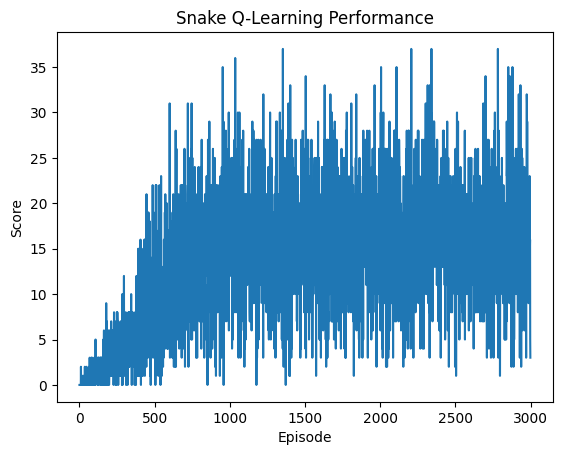

In [8]:
# Training Loop

# Parameters
NUM_EPISODES = 3000
MAX_STEPS = 500  # prevent infinite loops

agent = QLearningAgent(
    actions=[STRAIGHT, TURN_LEFT, TURN_RIGHT],
    alpha=0.1,          # 学习率
    gamma=0.9,          # 折扣因子
    epsilon=1.0,        # 初始探索率
    epsilon_min=0.01,   # 最小探索率
    epsilon_decay=0.995 # 探索率衰减
)

# Training logic
episode_rewards = []
episode_scores = []
episode_lengths = []

for episode in range(NUM_EPISODES):
    game = SnakeGame()
    state = get_state(game.snake, game.food, game.direction, GRID_SIZE)

    total_reward = 0
    steps = 0

    while not game.done and steps < MAX_STEPS:
        action = agent.choose_action(state)

        _, reward, done = step(game, action)

        next_state = get_state(
            game.snake,
            game.food,
            game.direction,
            GRID_SIZE
        )

        agent.update(state, action, reward, next_state)

        state = next_state
        total_reward += reward
        steps += 1

    agent.decay_epsilon()

    episode_rewards.append(total_reward)
    episode_scores.append(game.score)
    episode_lengths.append(steps)

    # Progress logging
    if episode % 100 == 0:
        print(
            f"Episode {episode} | "
            f"Score: {game.score} | "
            f"Steps: {steps} | "
            f"Epsilon: {agent.epsilon:.3f}"
        )

import matplotlib.pyplot as plt

plt.plot(episode_scores)
plt.xlabel("Episode")
plt.ylabel("Score")
plt.title("Snake Q-Learning Performance")
plt.show()

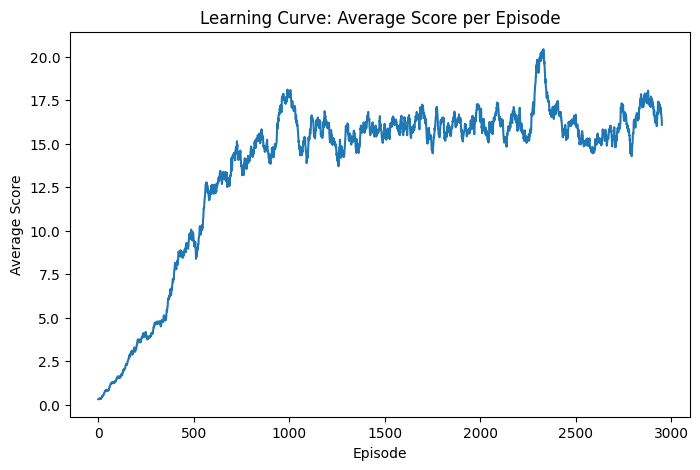

In [9]:
# Evaluation
import numpy as np

# Smooth curve
window = 50
smoothed_scores = np.convolve(
    episode_scores,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 5))
plt.plot(smoothed_scores)
plt.xlabel("Episode")
plt.ylabel("Average Score")
plt.title("Learning Curve: Average Score per Episode")
plt.show()

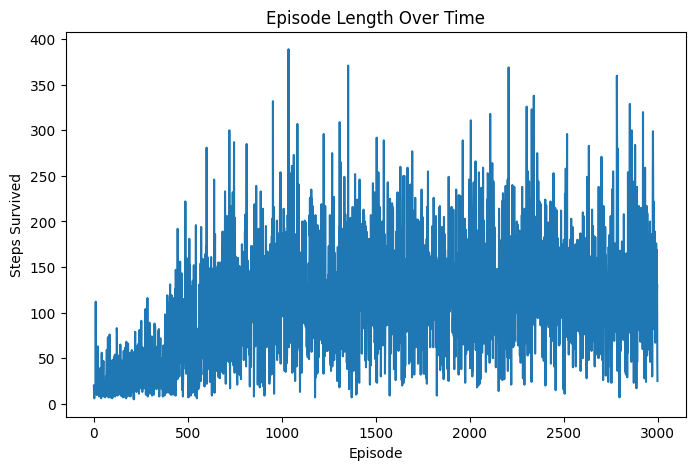

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(episode_lengths)
plt.xlabel("Episode")
plt.ylabel("Steps Survived")
plt.title("Episode Length Over Time")
plt.show()

In [11]:
pip install pygame

Note: you may need to restart the kernel to use updated packages.


In [12]:
import pygame
import sys
import time

CELL_SIZE = 30
GRID_SIZE = 10
WINDOW_SIZE = GRID_SIZE * CELL_SIZE

WHITE = (255, 255, 255)
BLACK = (0, 0, 0)
GREEN = (0, 200, 0)
RED = (200, 0, 0)
BLUE = (0, 0, 200)

FPS = 10

pygame 2.6.1 (SDL 2.28.4, Python 3.8.7)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [13]:
def draw_grid(screen):
    for x in range(0, WINDOW_SIZE, CELL_SIZE):
        pygame.draw.line(screen, BLACK, (x, 0), (x, WINDOW_SIZE))
    for y in range(0, WINDOW_SIZE, CELL_SIZE):
        pygame.draw.line(screen, BLACK, (0, y), (WINDOW_SIZE, y))


def draw_snake(screen, snake):
    for segment in snake:
        rect = pygame.Rect(
            segment[0] * CELL_SIZE,
            segment[1] * CELL_SIZE,
            CELL_SIZE,
            CELL_SIZE
        )
        pygame.draw.rect(screen, GREEN, rect)


def draw_food(screen, food):
    rect = pygame.Rect(
        food[0] * CELL_SIZE,
        food[1] * CELL_SIZE,
        CELL_SIZE,
        CELL_SIZE
    )
    pygame.draw.rect(screen, RED, rect)

In [14]:
def run_visualization(agent):
    pygame.init()
    screen = pygame.display.set_mode((WINDOW_SIZE, WINDOW_SIZE + 40))
    pygame.display.set_caption("Snake Q-Learning Demo")
    clock = pygame.time.Clock()
    font = pygame.font.SysFont(None, 30)

    game = SnakeGame()
    state = get_state(game.snake, game.food, game.direction, GRID_SIZE)

    while True:
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                pygame.quit()
                sys.exit()

        # Agent chooses best action (no exploration)
        action = agent.choose_action(state)
        agent.epsilon = 0.0  # force exploitation

        _, _, done = step(game, action)
        state = get_state(game.snake, game.food, game.direction, GRID_SIZE)

        if done:
            time.sleep(1)
            game = SnakeGame()
            state = get_state(game.snake, game.food, game.direction, GRID_SIZE)

        screen.fill(WHITE)
        draw_grid(screen)
        draw_snake(screen, game.snake)
        draw_food(screen, game.food)

        score_text = font.render(f"Score: {game.score}", True, BLUE)
        screen.blit(score_text, (10, WINDOW_SIZE + 5))

        pygame.display.flip()
        clock.tick(FPS)